## **1. Notebook Title + Objective**

**Trader Performance vs Market Sentiment Analysis**

**Objective**

The objective of this analysis is to examine how market sentiment (Fear vs Greed) affects trader performance and behavior.

This includes analyzing key metrics such as profitability (PnL), win rate, trade frequency, and position size, and identifying behavioral patterns across different sentiment conditions.

The goal is to derive actionable insights and strategy recommendations that can improve trading performance under varying market conditions.

## **2. Import + Load Data**

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
df1 = pd.read_csv(r"C:\Users\rudra\OneDrive\Desktop\Primetrade.ai_assignment\data\fear_greed_index.csv")
bitcoin = df1.copy()
df2 = pd.read_csv(r"C:\Users\rudra\OneDrive\Desktop\Primetrade.ai_assignment\data\historical_data.csv")
trader_data = df2.copy()

In [5]:
trader_data.columns = trader_data.columns.str.lower().str.replace(' ', '_')
bitcoin.columns = bitcoin.columns.str.lower().str.replace(' ', '_')

## **3. Data Preparation**

### **3.1. i) Dataset Health Check - `fear_greed_index`** 

- The dataset contains **2,644 rows and 4 columns**.  
- There are **no missing values or duplicate rows** in the dataset.  
- The dataset includes **5 sentiment categories**: *Fear, Extreme Fear, Neutral, Greed, Extreme Greed*.  
- The data spans from **February 2018 to May 2025**.  
- It includes a Unix timestamp column, which was converted into a readable datetime format and further standardized to a **daily level** for alignment with trader data.

In [8]:
bitcoin.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [10]:
bitcoin.shape

(2644, 4)

In [11]:
bitcoin.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [12]:
bitcoin.duplicated().sum()

0

In [13]:
bitcoin["classification"].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

### **3.1. ii) Data Cheaning - `fear_greed_index`**

In [15]:
bitcoin['date'] = pd.to_datetime(bitcoin['timestamp'], unit='s').dt.floor('D')
bitcoin = bitcoin[['date', 'classification']]

In [16]:
bitcoin.head()

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [17]:
bitcoin["date"].min()

Timestamp('2018-02-01 00:00:00')

In [18]:
bitcoin["date"].max()

Timestamp('2025-05-02 00:00:00')

In [19]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            2644 non-null   datetime64[ns]
 1   classification  2644 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 41.4+ KB


### **3.2. i) Dataset Health Check - `historical_data`**  

- The dataset contains **211,224 rows and 16 columns**.  
- There are **no missing values or duplicate rows** in the dataset.  
- The dataset includes **32 unique trader accounts**.  
- The data spans from **May 2023 to May 2025**.  
- The `timestamp_ist` column was initially in string format and was converted to a proper datetime format using `pd.to_datetime()` with `dayfirst=True`.  
- A new **date** column was created by extracting the daily component from the timestamp to enable alignment with sentiment data.

In [21]:
trader_data.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [22]:
trader_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   coin              211224 non-null  object 
 2   execution_price   211224 non-null  float64
 3   size_tokens       211224 non-null  float64
 4   size_usd          211224 non-null  float64
 5   side              211224 non-null  object 
 6   timestamp_ist     211224 non-null  object 
 7   start_position    211224 non-null  float64
 8   direction         211224 non-null  object 
 9   closed_pnl        211224 non-null  float64
 10  transaction_hash  211224 non-null  object 
 11  order_id          211224 non-null  int64  
 12  crossed           211224 non-null  bool   
 13  fee               211224 non-null  float64
 14  trade_id          211224 non-null  float64
 15  timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [23]:
trader_data.shape

(211224, 16)

In [24]:
trader_data.isnull().sum()

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64

In [25]:
trader_data.duplicated().sum()

0

In [26]:
trader_data["account"].nunique()

32

### **3.2. ii) Data Cheaning - `historical_data`**

In [28]:
trader_data['timestamp_ist'] = pd.to_datetime(
    trader_data['timestamp_ist'],
    dayfirst=True)

trader_data['date'] = pd.to_datetime(trader_data['timestamp_ist']).dt.floor('D')

In [29]:
trader_data.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [30]:
trader_data["date"].min()

Timestamp('2023-05-01 00:00:00')

In [31]:
trader_data["date"].max()

Timestamp('2025-05-01 00:00:00')

In [32]:
trader_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp_ist     211224 non-null  datetime64[ns]
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  object        
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

## **4. Core Metrics**

### **4.1. Win flag + long flag**

In [35]:
trader_data['win'] = trader_data['closed_pnl'] > 0
trader_data['is_long'] = trader_data['side'] == 'BUY'

### **4.2. Daily metrics per account**

In [37]:
daily_metrics = trader_data.groupby(['account', 'date']).agg(
    daily_pnl=('closed_pnl', 'sum'),
    avg_trade_size=('size_usd', 'mean'),
    trade_count=('trade_id', 'count'),
    win_rate=('win', 'mean'),
    long_ratio=('is_long', 'mean')
).reset_index()

In [38]:
daily_metrics

,account,date,daily_pnl,avg_trade_size,trade_count,win_rate,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,5089.718249,177,0.000000,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,7976.664412,68,0.000000,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,23734.500000,40,0.000000,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,28186.666667,12,0.000000,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,17248.148148,27,0.444444,0.444444
...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,2153.859390,82,0.390244,0.609756
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,1495.538419,430,0.393023,0.381395
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,1939.739989,902,0.441242,0.478936
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,1748.805333,75,0.520000,0.666667


## **5. Merge with sentiment**

In [40]:
df = pd.merge(daily_metrics, bitcoin, on='date', how='left')

In [41]:
df.head()

,account,date,daily_pnl,avg_trade_size,trade_count,win_rate,long_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,5089.718249,177,0.000000,0.000000,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,7976.664412,68,0.000000,0.000000,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,23734.500000,40,0.000000,0.000000,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,28186.666667,12,0.000000,1.000000,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,17248.148148,27,0.444444,0.444444,Extreme Greed


## **6. Analysis**

### **Fear vs Greed performance**

In [108]:
perf = df.groupby('classification')[['daily_pnl','win_rate']].mean().reset_index()

In [110]:
pref

,daily_pnl,win_rate
classification,,
Extreme Fear,4619.439053,0.329659
Extreme Greed,5161.922644,0.386387
Fear,5328.818161,0.364033
Greed,3318.100730,0.343559
Neutral,3438.618818,0.355414


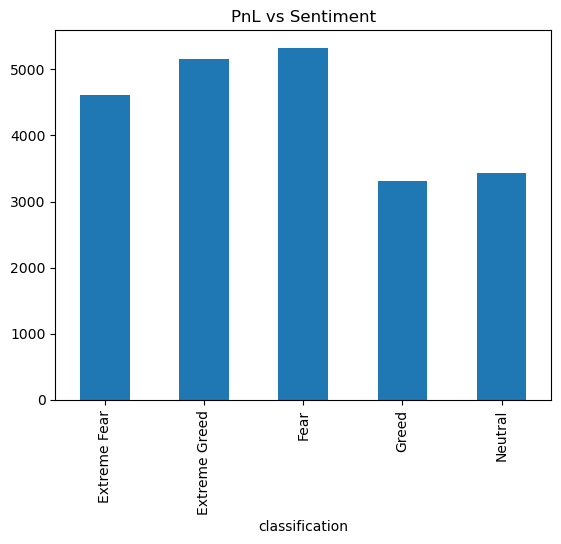

In [100]:
df.groupby('classification')['daily_pnl'].mean().plot(kind='bar', title='PnL vs Sentiment')
plt.show()

### **Behavior change**

In [114]:
behavior = df.groupby('classification')[['trade_count', 'avg_trade_size', 'long_ratio']].mean()
behavior

,trade_count,avg_trade_size,long_ratio
classification,,,
Extreme Fear,133.750000,6773.464125,0.531533
Extreme Greed,76.030418,5371.637182,0.473116
Fear,98.153968,8975.928546,0.518967
Greed,77.628086,6427.866594,0.471594
Neutral,100.228723,6963.694861,0.472431


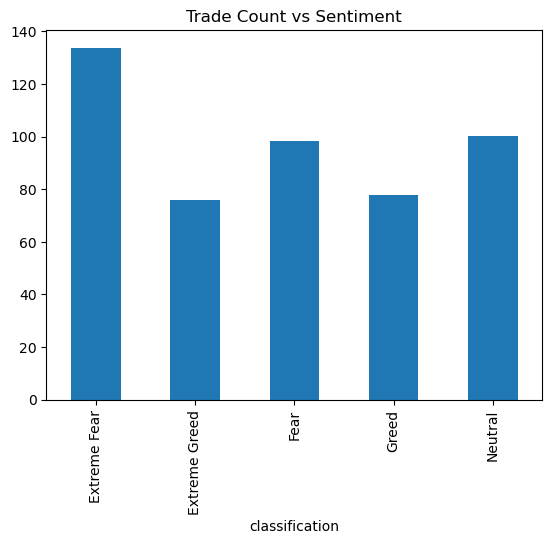

In [102]:
df.groupby('classification')['trade_count'].mean().plot(kind='bar', title='Trade Count vs Sentiment')
plt.show()

## **7. Segmentation**

### **Segment 1: High vs Low risk**

In [51]:
df['risk_level'] = df['avg_trade_size'].apply(
    lambda x: 'high' if x > df['avg_trade_size'].median() else 'low'
)

In [122]:
risk = df.groupby(['classification', 'risk_level'])['daily_pnl'].mean().reset_index()
risk

,classification,risk_level,daily_pnl
0,Extreme Fear,high,8445.038316
1,Extreme Fear,low,60.163219
2,Extreme Greed,high,6505.194438
3,Extreme Greed,low,3734.367129
4,Fear,high,9871.490346
5,Fear,low,1172.756375
6,Greed,high,4312.582036
7,Greed,low,2260.276665
8,Neutral,high,6403.719647
9,Neutral,low,829.330088


### **Segment 2: Frequent vs Infrequent**

In [126]:
df['freq_group'] = df['trade_count'].apply(
    lambda x: 'high' if x > df['trade_count'].median() else 'low'
)
freq = df.groupby(['classification', 'freq_group'])['daily_pnl'].mean().reset_index()
freq 

,classification,freq_group,daily_pnl
0,Extreme Fear,high,6799.753651
1,Extreme Fear,low,457.020275
2,Extreme Greed,high,8437.437459
3,Extreme Greed,low,1627.473851
4,Fear,high,10311.492505
5,Fear,low,913.034911
6,Greed,high,5486.377107
7,Greed,low,1401.949513
8,Neutral,high,5759.162182
9,Neutral,low,1118.075454


### **Segment 3: Consistency**

In [130]:
df['consistency'] = df['win_rate'].apply(lambda x: 'consistent' if x > 0.6 else 'inconsistent')

consistency = df.groupby(['classification', 'consistency'])['daily_pnl'].mean().reset_index()
consistency 

,classification,consistency,daily_pnl
0,Extreme Fear,consistent,15769.374550
1,Extreme Fear,inconsistent,1722.211719
2,Extreme Greed,consistent,14300.157150
3,Extreme Greed,inconsistent,1879.714385
4,Fear,consistent,14994.220063
5,Fear,inconsistent,1756.821806
6,Greed,consistent,9562.482671
7,Greed,inconsistent,1354.856915
8,Neutral,consistent,10960.419741
9,Neutral,inconsistent,823.512404


## **8. Insights**

### **1. Performance vs Sentiment**

Trader performance varies significantly with market sentiment.

The highest average PnL is observed during **Fear (~5328)**, followed by **Extreme Greed (~5161)** and **Extreme Fear (~4619)**.

In contrast, performance declines during **Greed (~3318)** and **Neutral (~3438)** phases, indicating that **volatile market conditions tend to provide more trading opportunities compared to relatively stable environments**.


### **2. Behavioral Patterns**

Traders exhibit clear behavioral shifts based on sentiment.

During **Extreme Fear**, trade frequency is highest (~133 trades/day), indicating **panic-driven overtrading**.

In contrast, **Extreme Greed** shows lower activity (~76 trades/day), suggesting more selective trading behavior.

Additionally, **average trade size peaks during Fear (~8975 USD)**, indicating increased risk-taking during uncertain market conditions.


### **3. Risk-Based Segmentation**

High-risk traders (larger trade sizes) consistently outperform low-risk traders across all sentiment conditions.

The gap is especially large during **Fear (~9871 vs ~1172)**, indicating that **higher risk-taking can lead to greater returns in volatile markets**, although it may also involve increased exposure to losses.


### **4. Frequency-Based Segmentation**

High-frequency traders consistently outperform low-frequency traders across all market conditions.

The performance gap is especially large during **Fear and Extreme Fear periods**, where high-frequency traders generate significantly higher profits.

This suggests that **active trading strategies are more effective in volatile market conditions**, enabling traders to capitalize on short-term price movements.


### **5. Consistency-Based Segmentation**

Consistent traders (win rate > 60%) significantly outperform inconsistent traders across all market sentiment conditions.

The performance gap is substantial, indicating that **trading discipline and execution quality play a more critical role than market sentiment alone**.

For example, during Greed periods, consistent traders achieve ~9562 average PnL compared to ~1354 for inconsistent traders, highlighting the importance of maintaining a high success rate in trades.

## **9. Final Strategy**

### **Strategy 1: Fear Market Strategy**

During **Fear** and **Extreme Fear** conditions:
- Reduce trade frequency and focus on **high-conviction trades**
- Avoid excessive trading, as it can reduce profitability
- Maintain **moderately larger position sizes** to capture volatility-driven opportunities

### **Strategy 2: Greed Market Strategy**

During **Greed** and **Extreme Greed** phases:
- Maintain **consistency and controlled risk exposure**
- Focus on **trade quality rather than quantity**
- Avoid overtrading despite positive market sentiment

### **Strategy 3: General Trading Principles**

- Prioritize **consistency (win rate)** over aggressive trading
- Control trade frequency to avoid overtrading
- Use **trade size as a controlled risk factor** *(leverage data not available)*

### **Final Insight**

> Trader success is driven more by **discipline, consistency, and risk management** than by market sentiment alone.